# Titanic Dataset Classification

## Objective

The objective of this notebook is to compare the performance of five machine learning classification algorithms on the Titanic dataset.

## Reference workflow

The notebook explores the Titanic passenger data, handles missing values, converts categorical fields to numeric features, and compares classifiers using a shared stratified train/test split. Run the cells in order; plots and reports are written to `../Results/`.

In [1]:
# Install notebook dependencies once if they are not already available in the environment.
from debugpy.adapter.components import missing
%pip install pandas numpy scikit-learn matplotlib seaborn xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the data, plotting, and numerical tools used throughout the analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# PassengerId identifies rows but is not used as a predictive feature.
df = pd.read_csv("../Data/titanic.csv", index_col = 'PassengerId')
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [6]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

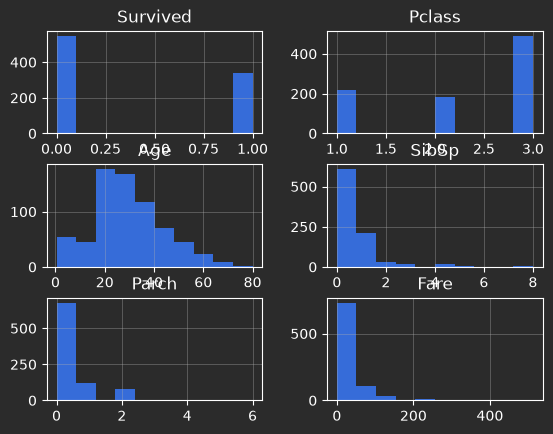

In [7]:
df.hist()

In [8]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [9]:
# Count missing values before choosing an imputation strategy.
missing_value_counts = df.isnull().sum()
missing_value_counts

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

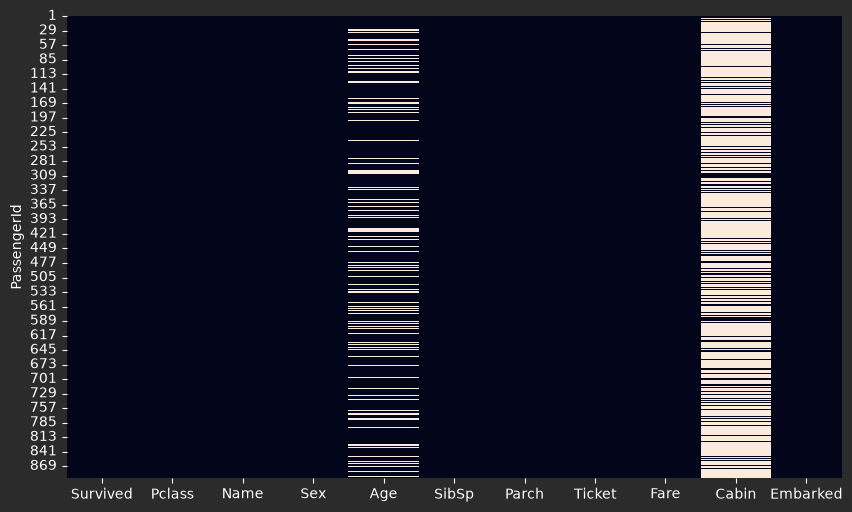

In [10]:
# Visualize missing values

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar = False)
plt.show()

In [11]:
# Use robust/frequent-value imputation, then remove high-cardinality or sparse text fields.
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns = ['Name', 'Ticket', 'Cabin'])

In [12]:
# Convert categorical features to numeric indicators; drop one level to avoid redundancy.

df = pd.get_dummies(df, columns = ['Sex', 'Embarked'], drop_first = True)

In [13]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,
1,0,3,22.0,1,0,7.2500,True,False,True
2,1,1,38.0,1,0,71.2833,False,False,False
3,1,3,26.0,0,0,7.9250,False,False,True
4,1,1,35.0,1,0,53.1000,False,False,True
5,0,3,35.0,0,0,8.0500,True,False,True


In [14]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='str')

In [15]:
# Separate predictors from the survival label to avoid target leakage.
X = df.drop('Survived', axis = 1)
Y = df['Survived']

In [16]:
from utils.preprocessing import split_data, scale_data

# The shared helpers perform a stratified split and fit scaling on training data only.
X_train, X_test, Y_train, Y_test = split_data(X, Y)

X_train_scaled, X_test_scaled = scale_data(
    X_train,
    X_test
)

Saving confusion matrix to: ../Results/confusion_matrices\Titanic_logistic_regression.png


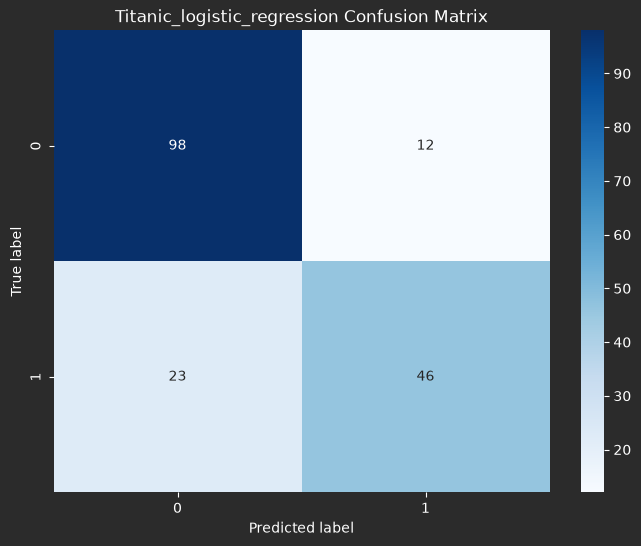


Classification Report - logistic_regression
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Saving JSON to: ../Results/Titanic_logistic_regression_20260814_174700.json

Model: logistic_regression
{'accuracy': 0.8044692737430168, 'precision': 0.8034360168823663, 'recall': 0.8044692737430168, 'f1': 0.8006569011275826, 'confusion_matrix': [[98, 12], [23, 46]], 'classification_report': {'0': {'precision': 0.8099173553719008, 'recall': 0.8909090909090909, 'f1-score': 0.8484848484848485, 'support': 110.0}, '1': {'precision': 0.7931034482758621, 'recall': 0.6666666666666666, 'f1-score': 0.7244094488188977, 'support': 69.0}, 'accuracy': 0.8044692737430168, 'macro avg': {'precision': 0.8015104018238814, 'recall': 0.7787

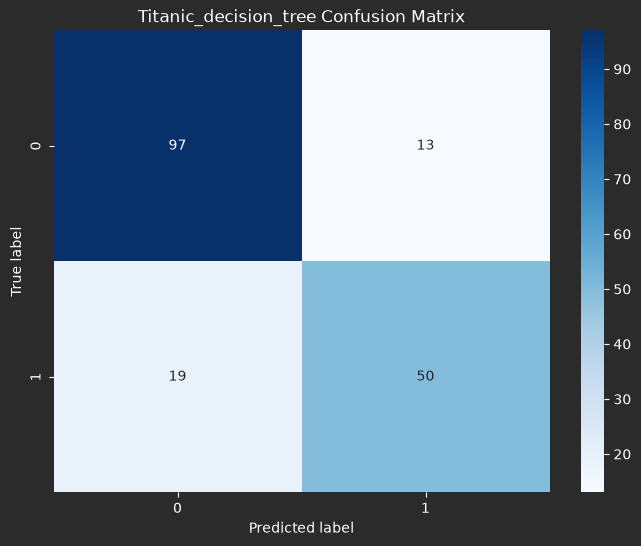


Classification Report - decision_tree
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

Saving JSON to: ../Results/Titanic_decision_tree_20260814_174701.json

Model: decision_tree
{'accuracy': 0.8212290502793296, 'precision': 0.8198025887295777, 'recall': 0.8212290502793296, 'f1': 0.819539139853571, 'confusion_matrix': [[97, 13], [19, 50]], 'classification_report': {'0': {'precision': 0.8362068965517241, 'recall': 0.8818181818181818, 'f1-score': 0.8584070796460177, 'support': 110.0}, '1': {'precision': 0.7936507936507936, 'recall': 0.7246376811594203, 'f1-score': 0.7575757575757576, 'support': 69.0}, 'accuracy': 0.8212290502793296, 'macro avg': {'precision': 0.8149288451012588, 'recall': 0.8032279314888011, 'f1-s

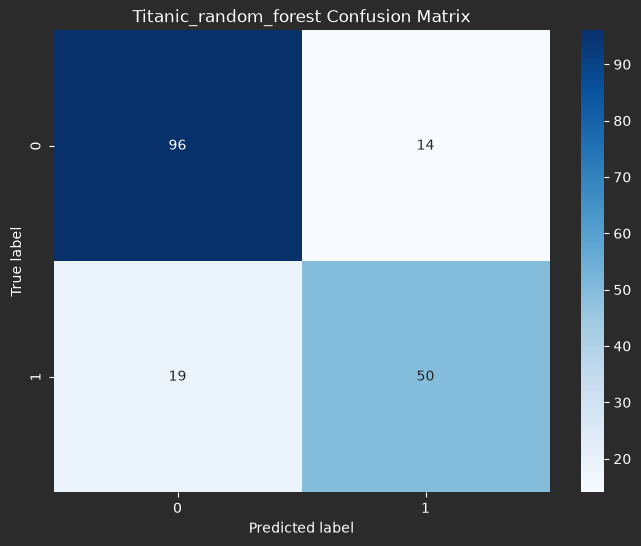


Classification Report - random_forest
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

Saving JSON to: ../Results/Titanic_random_forest_20260814_174701.json

Model: random_forest
{'accuracy': 0.8156424581005587, 'precision': 0.814147133835317, 'recall': 0.8156424581005587, 'f1': 0.8142255079038377, 'confusion_matrix': [[96, 14], [19, 50]], 'classification_report': {'0': {'precision': 0.8347826086956521, 'recall': 0.8727272727272727, 'f1-score': 0.8533333333333334, 'support': 110.0}, '1': {'precision': 0.78125, 'recall': 0.7246376811594203, 'f1-score': 0.7518796992481203, 'support': 69.0}, 'accuracy': 0.8156424581005587, 'macro avg': {'precision': 0.8080163043478261, 'recall': 0.7986824769433465, 'f1-score': 0.80

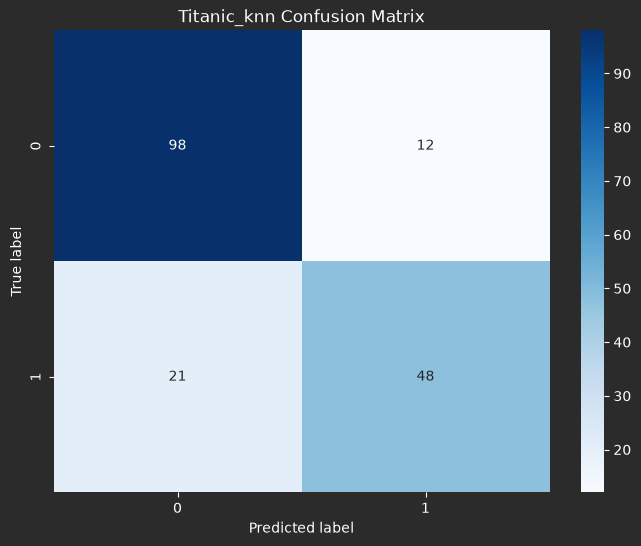


Classification Report - knn
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179

Saving JSON to: ../Results/Titanic_knn_20260814_174701.json

Model: knn
{'accuracy': 0.8156424581005587, 'precision': 0.8144594150509366, 'recall': 0.8156424581005587, 'f1': 0.8128341275140941, 'confusion_matrix': [[98, 12], [21, 48]], 'classification_report': {'0': {'precision': 0.8235294117647058, 'recall': 0.8909090909090909, 'f1-score': 0.8558951965065502, 'support': 110.0}, '1': {'precision': 0.8, 'recall': 0.6956521739130435, 'f1-score': 0.7441860465116279, 'support': 69.0}, 'accuracy': 0.8156424581005587, 'macro avg': {'precision': 0.8117647058823529, 'recall': 0.7932806324110672, 'f1-score': 0.8000406215090891, 'support': 179.0}

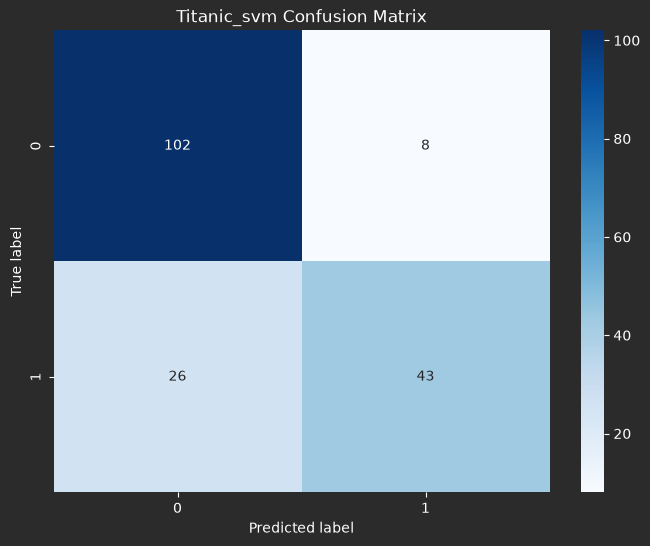


Classification Report - svm
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179

Saving JSON to: ../Results/Titanic_svm_20260814_174702.json

Model: svm
{'accuracy': 0.8100558659217877, 'precision': 0.8147079362471246, 'recall': 0.8100558659217877, 'f1': 0.8029928172386271, 'confusion_matrix': [[102, 8], [26, 43]], 'classification_report': {'0': {'precision': 0.796875, 'recall': 0.9272727272727272, 'f1-score': 0.8571428571428571, 'support': 110.0}, '1': {'precision': 0.8431372549019608, 'recall': 0.6231884057971014, 'f1-score': 0.7166666666666667, 'support': 69.0}, 'accuracy': 0.8100558659217877, 'macro avg': {'precision': 0.8200061274509804, 'recall': 0.7752305665349144, 'f1-score': 0.7869047619047619, 'support': 1

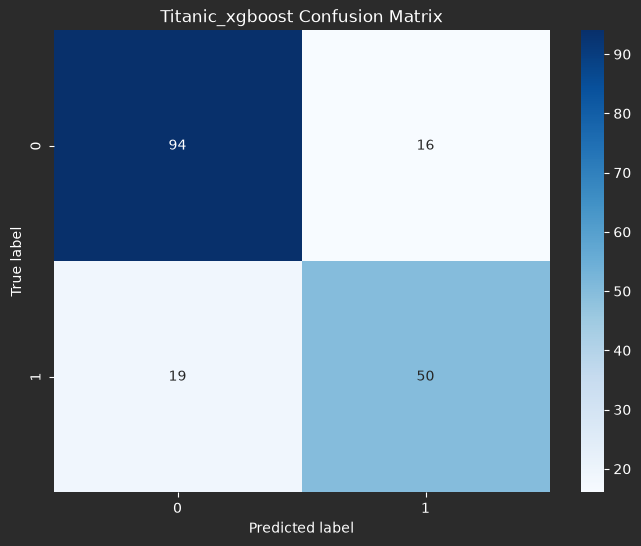


Classification Report - xgboost
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Saving JSON to: ../Results/Titanic_xgboost_20260814_174702.json

Model: xgboost
{'accuracy': 0.8044692737430168, 'precision': 0.8032243131368064, 'recall': 0.8044692737430168, 'f1': 0.8036119392183224, 'confusion_matrix': [[94, 16], [19, 50]], 'classification_report': {'0': {'precision': 0.831858407079646, 'recall': 0.8545454545454545, 'f1-score': 0.8430493273542601, 'support': 110.0}, '1': {'precision': 0.7575757575757576, 'recall': 0.7246376811594203, 'f1-score': 0.7407407407407407, 'support': 69.0}, 'accuracy': 0.8044692737430168, 'macro avg': {'precision': 0.7947170823277018, 'recall': 0.7895915678524374, 'f1-score': 0.791895034

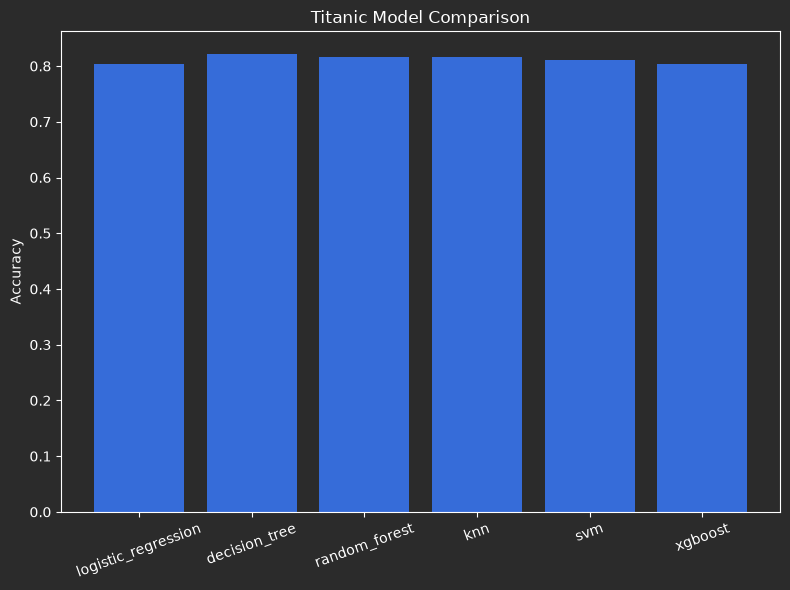

In [17]:
from Models.pipeline import run_pipeline
from utils.logger import save_accuracy_table
from utils.visualization import plot_accuracy_graph

# This label is reused in result filenames and plot titles.
dataset_name = "Titanic"

models = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "knn",
    "svm",
    "xgboost"
]

all_results = []

# Train every candidate under the same split and collect comparable metrics.
for model in models:

    results = run_pipeline(
        X_train,
        X_test,
        X_train_scaled,
        X_test_scaled,
        Y_train,
        Y_test,
        model,
        "Titanic"
    )

    all_results.append({
        "Model": model,
        "Accuracy": results["accuracy"],
        "Precision": results["precision"],
        "Recall": results["recall"],
        "F1": results["f1"]
    })

    print(f"\n{'='*50}")
    print(f"Model: {model}")
    print(results)

# Persist the comparison and create a visual summary after all runs finish.
save_accuracy_table(dataset_name, all_results)
plot_accuracy_graph(dataset_name, all_results)

In [18]:
# Find best model based on accuracy
best_model = max(
    all_results,
    key=lambda x: x["Accuracy"]
)

print("\n" + "=" * 60)
print("BEST PERFORMING MODEL")
print("=" * 60)

print(f"Dataset   : {dataset_name}")
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1 Score  : {best_model['F1']:.4f}")


BEST PERFORMING MODEL
Dataset   : Titanic
Model     : decision_tree
Accuracy  : 0.8212
Precision : 0.8198
Recall    : 0.8212
F1 Score  : 0.8195
